In [1]:
import numpy as np
import pandas as pd
import sys
import xarray as xr

import sys
sys.path.append("../")
from experiments import utils

from sklearn.metrics import completeness_score, silhouette_score, mean_squared_error
from datetime import datetime, timedelta

from package_name.model.utils import sampling
from package_name.training.trainer import VAETrainer, VAEConfig
from package_name.tuning.cross_validator import CrossValidator
from package_name.inference.predictor import VAEPredictor

from package_name.evaluation import plots as eval_plots
from package_name.evaluation import metrics


from package_name.evaluation import plots as eval_plots
from package_name.evaluation import metrics
from package_name.evaluation.pca_kmeans import PCAKmeansPredictor
from typing import Any, Literal



I0000 00:00:1784571030.944606  668549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784571031.003321  668549 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784571033.946477  668549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
winter_months = [12, 1, 2]
years = list(range(1940, 2023))

In [ ]:
import yaml
from yaml import CLoader as Loader
import os

#---------------------------------------- Read the config file ----------------------------------------

#if file exists
if os.path.exists("results/cmm_config.yaml"):
    stream = open("results/cmm_config.yaml", 'r')
    dictionary = yaml.load(stream, Loader=Loader)
    
    cluster_number = dictionary['cluster_number']

    pr_cluster_number = dictionary['pr_cluster_number']
    original_dim = dictionary['original_dim']

    latent_dim = dictionary['latent_dim']

    activation_function = dictionary['activation_function']

    dim_layer1 = dictionary['dim_layer1']
    dim_layer2 = dictionary['dim_layer2']
    dim_layer3 = dictionary['dim_layer3']

    batch_size = dictionary['batch_size']
    epochs = dictionary['epochs']

    reconstruction_loss_factor = 0.5

else:
    cluster_number = 4
    
    pr_cluster_number = 4
    original_dim = 575
    
    latent_dim = 10
    
    activation_function = "relu"
    
    dim_layer1=256
    dim_layer2=128
    dim_layer3=64
    
    batch_size = 128
    epochs = 500
    
    reconstruction_loss_factor = 0.5
    
    

In [4]:
data='/home/vselvakumar/Documents/Codes/ECMWF/C4E/data_publication'

In [5]:
#---------------------------------------- Initialize the VAE model ----------------------------------------

config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=dim_layer1,
    dim_layer2=dim_layer2,
    dim_layer3=dim_layer3,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=latent_dim,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

vae = VAEPredictor(cfg=config)

E0000 00:00:1784565133.714533  358266 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
#load the weights of the trained model
chosen_count = 0  #model train
vae.load_weights(f"results/final_weights_{cluster_number}_{chosen_count}.weights.h5")


In [7]:
# Get reanalysis data
z500 = utils.preprocess_dataset(filename =f'{data}/era5_z500_daily_250_atlantic_1940_2022.nc',
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'extended europe',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 2003, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)

In [8]:
#get the latent representation of the data
encoder_outputs = vae.encode(
    input=z500_reshaped,
)

z_enc = encoder_outputs["z"]
c_enc = encoder_outputs["clusters_pred"]

cluster_probab = pd.DataFrame(
        data={
            "Method": "CMM-VAE",
            "valid_date": z500['time'].dt.date,
            **{str(i): c_enc[:, i] for i in range(cluster_number)}
        })
#save cluster probabilities
cluster_probab.to_csv(f'results/cond_prob_cmmvae_era5_{cluster_number}.csv', index=False)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


### PCA+kmeans

In [14]:
#---------------------------------------- PCA KMeans Predictor ----------------------------------------
pca_kmeans_predictor = PCAKmeansPredictor(
    model_dir="results/PCA/"
) #load the PCA KMeans model trained on ERA5 data

In [15]:
#get PCA KMeans cluster probabilities
cluster_probs = pca_kmeans_predictor.clusters(x=z500_reshaped)
c_enc = cluster_probs.T
cluster_probab = pd.DataFrame(
        data={
            "Method": "PCA-KMeans",
            "valid_date": z500['time'].dt.date,
            **{str(i): c_enc[:, i] for i in range(cluster_number)}
        })
#save cluster probabilities
cluster_probab.to_csv(f'results/cond_prob_pca_era5_{cluster_number}.csv', index=False)

# S2S forecasts

In [ ]:

ForecastMethod = Literal["vae", "pca_kmeans"]


def process_forecast_leadtime(
    ds_days_anom: xr.Dataset,
    leadtime: int,
    model: Any,
    method: ForecastMethod,
    cluster_number: int,
    n_members: int = 11,
    variable_name: str = "gh",
) -> pd.DataFrame:
    """
    Calculate ensemble-mean cluster probabilities for one lead time.

    Parameters
    ----------
    ds_days_anom
        Preprocessed forecast anomaly dataset.
    leadtime
        Forecast lead-time index.
    model
        VAE model when ``method="vae"`` or PCA-KMeans predictor when
        ``method="pca_kmeans"``.
    method
        Model used to calculate cluster probabilities.
    cluster_number
        Expected number of clusters.
    n_members
        Number of ensemble members to process.
    variable_name
        Name of the forecast variable.

    Returns
    -------
    pd.DataFrame
        Cluster probabilities averaged over ensemble members.
    """
    if method not in {"vae", "pca_kmeans"}:
        raise ValueError(
            "method must be 'vae' or 'pca_kmeans'."
        )

    available_members = ds_days_anom.sizes["number"]

    if n_members > available_members:
        raise ValueError(
            f"Requested {n_members} members, but the dataset "
            f"contains only {available_members}."
        )

    member_probabilities: list[np.ndarray] = []

    for member in range(n_members):
        selected = (
            ds_days_anom[variable_name]
            .isel(
                days=leadtime,
                number=member,
            )
            .transpose(
                "time",
                "latitude",
                "longitude",
            )
        )

        X = utils.reshape_data_for_clustering(selected)
        n_samples = X.shape[0]

        if method == "vae":
            encoder_outputs = model.encode(input=X)

            probabilities = np.asarray(
                encoder_outputs["clusters_pred"]
            )

        else:
            probabilities = np.asarray(
                model.clusters(x=X)
            )

            # PCA-KMeans may return (clusters, samples).
            if probabilities.shape == (
                cluster_number,
                n_samples,
            ):
                probabilities = probabilities.T

        expected_shape = (
            n_samples,
            cluster_number,
        )

        if probabilities.shape != expected_shape:
            raise ValueError(
                f"Unexpected probability shape for member {member}: "
                f"{probabilities.shape}. Expected {expected_shape}."
            )

        member_probabilities.append(probabilities)

    # Shape:
    # (members, forecast initializations, clusters)
    probabilities_stacked = np.stack(
        member_probabilities,
        axis=0,
    )

    # Average probabilities over the ensemble members.
    probabilities_mean = probabilities_stacked.mean(
        axis=0,
    )

    selected = (
        ds_days_anom[variable_name]
        .isel(days=leadtime, number=0)
    )

    forecast_init = pd.to_datetime(
        selected["time"].values
    )
    valid_date = forecast_init + pd.Timedelta(
        days=leadtime
    )

    method_name = (
        "CMM-VAE"
        if method == "vae"
        else "PCA-KMeans"
    )

    return pd.DataFrame(
        {
            "Method": method_name,
            "forecast_init": forecast_init.date,
            "valid_date": valid_date.date,
            "leadtime": leadtime,
            **{
                str(cluster): probabilities_mean[
                    :, cluster
                ]
                for cluster in range(cluster_number)
            },
        }
    )

In [ ]:
cprob_ls = []
cprob_ls_pca = []

chosen_count = 0
vae.load_weights(
    f"results/final_weights_{cluster_number}_{chosen_count}.weights.h5"
)

reference_dates_mmdd = ['0101', '0108', '0115', '0122', '0201', '0208', '0215', '0222', '1115', '1201', '1215']
fpath ='/net/helium/atmosdyn/vselvakumar/Data/C4E/Energy_var/s2s'

for reference_date in reference_dates_mmdd:

    print(reference_date)

    ds_days_anom = utils.preprocess_forecast_data(
        fpath=fpath,
        reference_date=reference_date,
        variable_name="gh",
        multiplication_factor=1.0,
        geographical_filter="extended europe",
        anomalies=True,
        normalization=True,
        rolling_window=5,
        spatial_resolution=2.5,
        weights=weights,
    )

    for leadtime in range(47):

        cprob_cmmvae = (
            process_forecast_leadtime(
                ds_days_anom=ds_days_anom,
                leadtime=leadtime,
                model=vae,
                method="vae",
                cluster_number=cluster_number,
                n_members=11,
            )
        )
        
        cprob_pca = (
            process_forecast_leadtime(
                ds_days_anom=ds_days_anom,
                leadtime=leadtime,
                model=pca_kmeans_predictor,
                method="pca_kmeans",
                cluster_number=cluster_number,
                n_members=11,
            )
        )
        
        cprob_ls.append(cprob_cmmvae) 
        cprob_ls_pca.append(cprob_pca)

cprobs_cmmvae = pd.concat(
    cprob_ls,
    ignore_index=True,
)
cprobs_pca = pd.concat(
    cprob_ls_pca,
    ignore_index=True,
)
cprobs_cmmvae.to_csv(
    f"results/cond_prob_cmmvae_forecast_{cluster_number}_{chosen_count}.csv",
    index=False,
)
cprobs_pca.to_csv(
    f"results/cond_prob_pca_forecast_{cluster_number}.csv",
    index=False,
)

0101
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━

# Evaluation

In [1]:
import sys
sys.path.append("../")
from package_name.evaluation.s2s_eval import plot_forecast_scores

I0000 00:00:1784571291.558026  822023 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784571291.613668  822023 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784571294.494929  822023 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
cluster_number = 4
chosen_count = 0

Processing CMM-VAE
Processing PCA


(<Figure size 3900x1500 with 2 Axes>,
 array([<Axes: title={'center': '(a) Brier skill score'}, xlabel='Lead time', ylabel='Brier skill score'>,
        <Axes: title={'center': '(b) ROC AUC'}, xlabel='Lead time', ylabel='Multiclass ROC AUC'>],
       dtype=object))

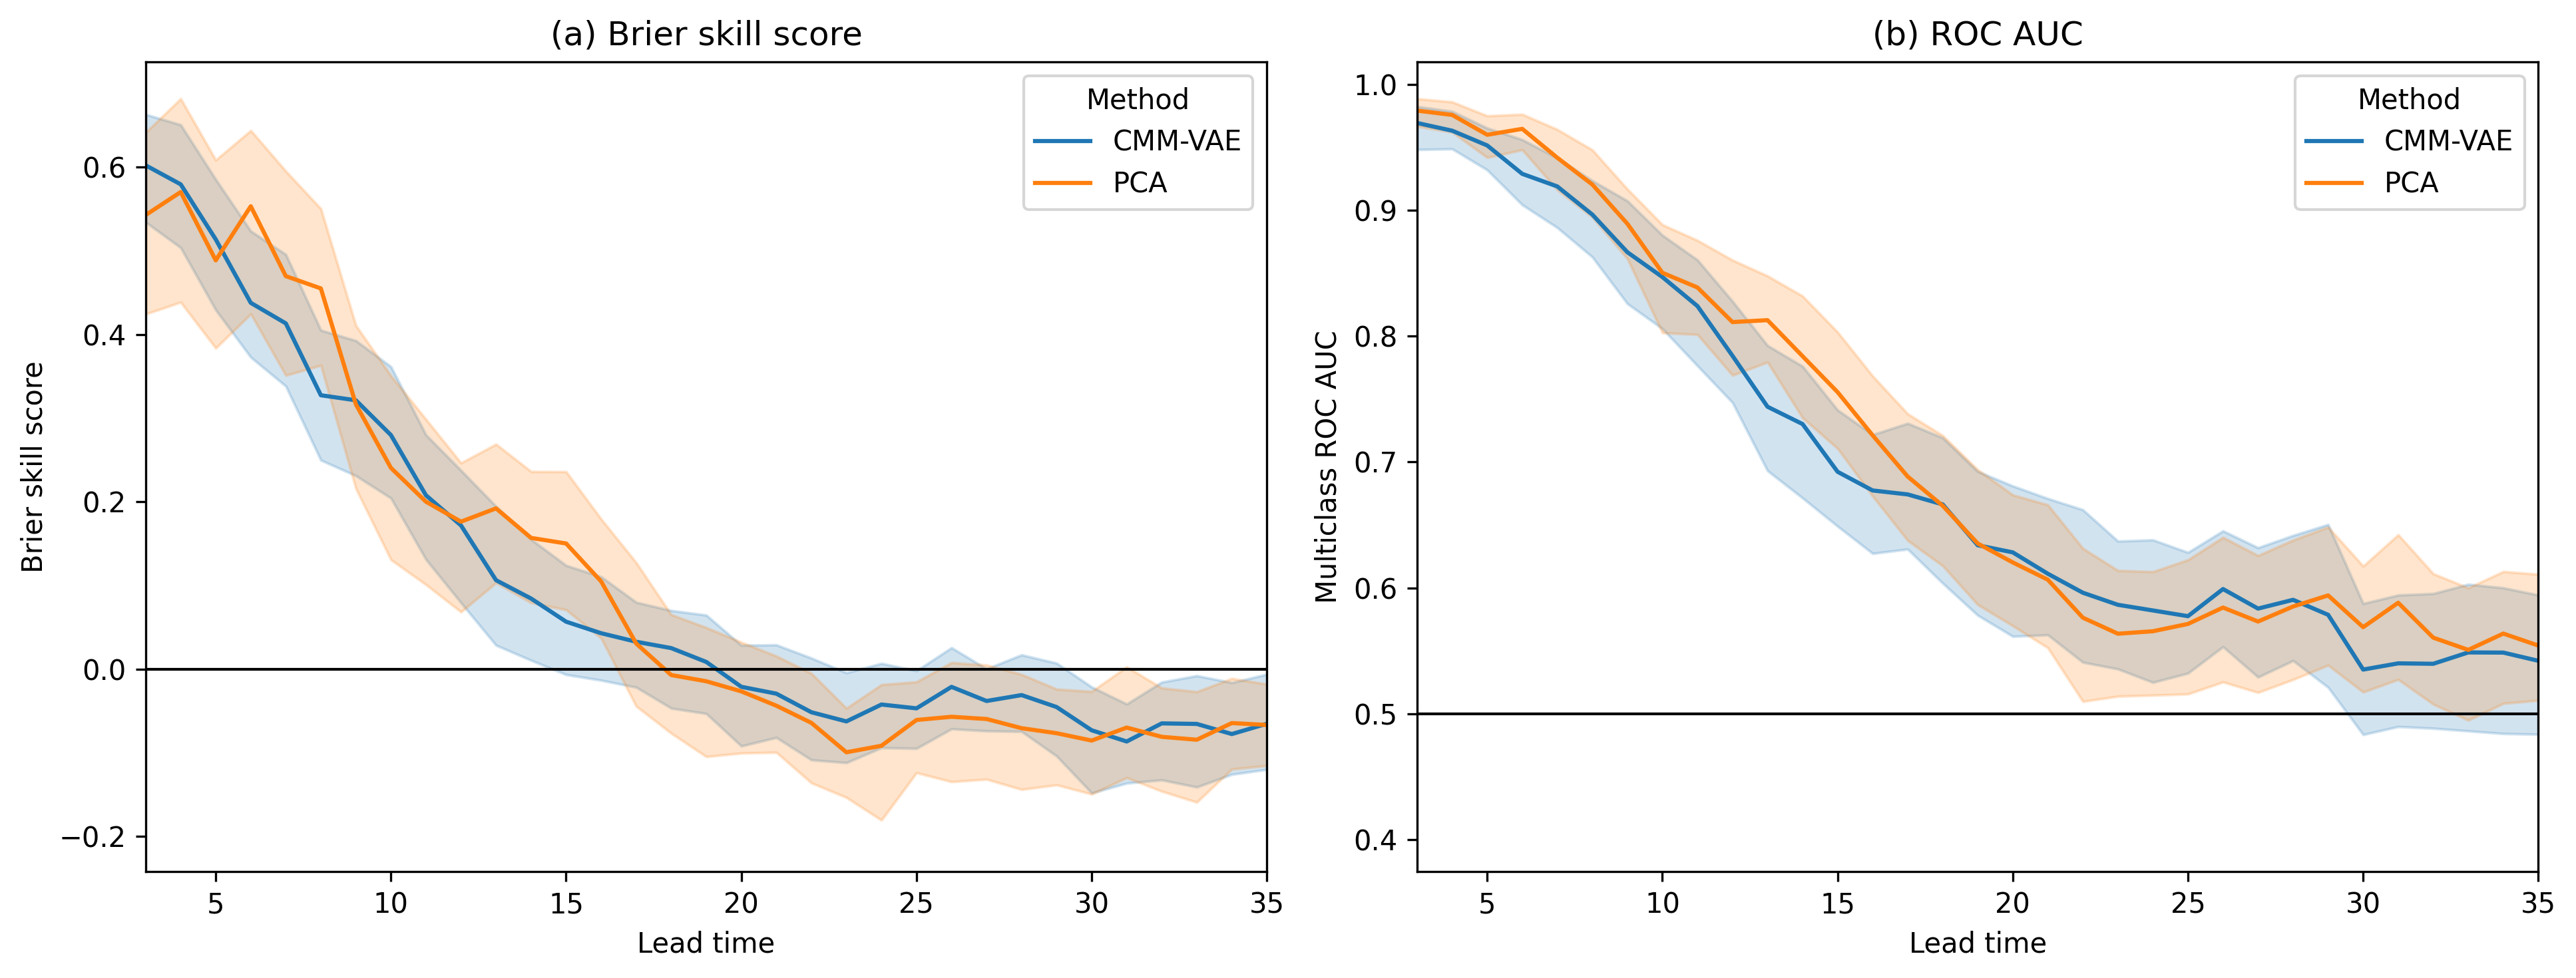

In [3]:
plot_forecast_scores(
    methods=["cmmvae", "pca"],
    cluster_number=cluster_number,
    chosen_count=chosen_count,
    n_bootstrap=100,
)